# ✈️ Predicción de Retrasos de Vuelos — Dataset Real (Kaggle)


# Descripción general y objetivos:

 Los retrasos en los vuelos afectan a millones de pasajeros cada año y pueden ocasionar la pérdida de conexiones, mayores costos y la insatisfacción de los clientes. En este proyecto, formarás parte de un equipo de científicos de datos que trabaja para una aerolínea. Tu objetivo es analizar datos históricos de vuelos, identificar los factores que contribuyen a los retrasos y desarrollar un modelo de aprendizaje automático capaz de predecir si un vuelo se retrasará.

 Este proyecto te guiará a través del ciclo de vida completo de la ciencia de datos, incluyendo la recopilación, limpieza, exploración, modelado, evaluación, visualización e implementación de datos.

 ---

**Dataset:** [2015 Flight Delays and Cancellations](https://www.kaggle.com/datasets/usdot/flight-delays) · usdot/flight-delays

-airlines.csv

-airports.csv

-flights.csv

**Bonus:** Regresión — predicción de minutos exactos de retraso

---

## Tabla de Contenidos
1. Configuración y carga de datos  
2. Task 1 — Data Understanding  
3. Task 2 — Data Cleaning  
4. Task 3 — Exploratory Data Analysis  
5. Task 4 — Feature Engineering  
6. Task 5 — Definición del problema  
7. Task 6 — Construcción de modelos  
8. Task 7 — Evaluación  
9. Task 8 — Interpretación  
10. Task 9 — Recomendaciones de negocio  
11. Bonus — Regresión  
12. Exportar artefactos para el dashboard

---
Author:Oscar Martinez Gracia

oskytm@hotmail.com

Created:2026-06-20

Finish:2026-06-22


## ⚙️ Instalación y configuración

In [1]:
# Instalar librerías adicionales (Colab ya trae pandas, numpy, matplotlib, seaborn, sklearn)
!pip install -q xgboost kaggle

In [2]:
import os, sys, warnings, json, zipfile
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score,
)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier, XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

IN_COLAB = "google.colab" in sys.modules
print("Ejecutando en Google Colab:", IN_COLAB)

Ejecutando en Google Colab: True


In [9]:
import os, sys, warnings, json, zipfile
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
    mean_absolute_error, mean_squared_error, r2_score,
)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier, XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

IN_COLAB = "google.colab" in sys.modules
print("Ejecutando en Google Colab:", IN_COLAB)


# ╔══════════════════════════════════════════════════════════════╗
# ║              CONFIGURACIÓN PRINCIPAL                         ║
# ╠══════════════════════════════════════════════════════════════╣
# ║  Cambia estas variables según cómo quieras cargar los datos  ║
# ╚══════════════════════════════════════════════════════════════╝

DATA_DIR        = "."          # carpeta donde están (o se descargarán) los CSV
USE_KAGGLE_API  = False           # True → descarga automática con kaggle.json
SAMPLE_SIZE     = 500_000         # None → usa el dataset completo (~5.8M filas)
                                  # Recomendado: empieza con 500_000 para iterar rápido
                                  # Pon None solo para la corrida final
DELAY_THRESHOLD = 15              # minutos: IS_DELAYED = 1 si DEPARTURE_DELAY > 15
RANDOM_STATE    = 42

os.makedirs(DATA_DIR, exist_ok=True)


Ejecutando en Google Colab: True


### Opción 1 — Descarga automática vía API de Kaggle

In [10]:
if IN_COLAB and USE_KAGGLE_API:
    from google.colab import files
    print("Sube tu archivo kaggle.json (Kaggle → Account → Create New API Token)")
    uploaded = files.upload()
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    for fname in uploaded:
        os.replace(fname, os.path.expanduser(f"~/.kaggle/{fname}"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    !kaggle datasets download -d usdot/flight-delays -p {DATA_DIR} --unzip
    print("Descarga completa.")
else:
    print("Omitiendo descarga API (USE_KAGGLE_API=False).")
    print("Sube flights.csv, airlines.csv y airports.csv a la carpeta data/ manualmente.")

Omitiendo descarga API (USE_KAGGLE_API=False).
Sube flights.csv, airlines.csv y airports.csv a la carpeta data/ manualmente.


### Carga de datos

In [11]:
flights_raw = pd.read_csv(
    os.path.join(DATA_DIR, "flights.csv"),
    low_memory=False,
    dtype={
        "ORIGIN_AIRPORT": str,
        "DESTINATION_AIRPORT": str,
        "AIRLINE": str,
    },
)
airlines_df = pd.read_csv(os.path.join(DATA_DIR, "airlines.csv"))
airports_df = pd.read_csv(os.path.join(DATA_DIR, "airports.csv"))
flights_df = pd.read_csv(os.path.join(DATA_DIR, "flights.csv"))

# Muestra aleatoria reproducible (para iterar rápido antes de la corrida final)
if SAMPLE_SIZE is not None and len(flights_raw) > SAMPLE_SIZE:
    flights_raw = flights_raw.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"Muestra de {SAMPLE_SIZE:,} filas cargada (SAMPLE_SIZE={SAMPLE_SIZE:,}).")
else:
    print("Dataset completo cargado.")

print(f"flights: {flights_raw.shape} | airlines: {airlines_df.shape} | airports: {airports_df.shape}")

Muestra de 500,000 filas cargada (SAMPLE_SIZE=500,000).
flights: (500000, 31) | airlines: (14, 2) | airports: (322, 7)


In [12]:
display(flights_raw.head(3))
display(airlines_df.head(3))
display(airports_df.head(3))

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,3,28,6,WN,1592,N436WN,LAS,RNO,2150,...,2254.0,-11.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,4,6,1,MQ,2968,N525MQ,STL,ORD,1450,...,1623.0,8.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,4,7,MQ,3097,N503MQ,ORD,MSP,1545,...,2015.0,182.0,0.0,0.0,NaN,0.0,0.0,0.0,124.0,58.0


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919


---
## Task 1 — Data Understanding (Comprensión de los Datos)


In [13]:
print(f"Filas: {flights_raw.shape[0]:,}   Columnas: {flights_raw.shape[1]}")
flights_raw.dtypes.to_frame("dtype")

Filas: 500,000   Columnas: 31


,dtype
YEAR,int64
MONTH,int64
DAY,int64
DAY_OF_WEEK,int64
AIRLINE,object
FLIGHT_NUMBER,int64
TAIL_NUMBER,object
ORIGIN_AIRPORT,object
DESTINATION_AIRPORT,object
SCHEDULED_DEPARTURE,int64


In [14]:
flights_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,500000.0,NaN,NaN,NaN,2015.0,0.0,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,500000.0,NaN,NaN,NaN,2.525832,1.120535,1.0,2.0,3.0,4.0,4.0
DAY,500000.0,NaN,NaN,NaN,15.454658,8.657395,1.0,8.0,15.0,23.0,31.0
DAY_OF_WEEK,500000.0,NaN,NaN,NaN,3.92465,1.984279,1.0,2.0,4.0,6.0,7.0
AIRLINE,500000,14,WN,106961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLIGHT_NUMBER,500000.0,NaN,NaN,NaN,2229.16138,1787.573823,1.0,749.0,1703.0,3430.0,9794.0
TAIL_NUMBER,497701,4553,N476HA,368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN_AIRPORT,500000,315,ATL,31966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION_AIRPORT,500000,315,ATL,31929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEPARTURE,500000.0,NaN,NaN,NaN,1325.810608,477.16352,1.0,920.0,1320.0,1725.0,2359.0


In [15]:
def missing_value_report(df):
    miss = df.isna().sum()
    pct  = miss / len(df) * 100
    return (
        pd.DataFrame({"missing_count": miss, "missing_pct": pct.round(2)})
        .query("missing_count > 0")
        .sort_values("missing_pct", ascending=False)
    )

missing_report = missing_value_report(flights_raw)
print(f"Columnas con valores faltantes: {len(missing_report)}")
missing_report

Columnas con valores faltantes: 18


,missing_count,missing_pct
CANCELLATION_REASON,487110,97.42
SECURITY_DELAY,401982,80.40
AIR_SYSTEM_DELAY,401982,80.40
LATE_AIRCRAFT_DELAY,401982,80.40
WEATHER_DELAY,401982,80.40
AIRLINE_DELAY,401982,80.40
ARRIVAL_DELAY,14044,2.81
ELAPSED_TIME,14044,2.81
AIR_TIME,14044,2.81
TAXI_IN,13160,2.63


**Análisis de variables (Deliverable: Dataset summary)**

| Grupo | Columnas | Uso |
|---|---|---|
| Temporales | YEAR, MONTH, DAY, DAY_OF_WEEK | Capturan ciclos de tráfico aéreo |
| Identificación | AIRLINE, FLIGHT_NUMBER | Aerolínea → historial de retrasos |
| Ruta | ORIGIN_AIRPORT, DESTINATION_AIRPORT, DISTANCE | Congestión y distancia |
| Horario | SCHEDULED_DEPARTURE, SCHEDULED_TIME | Hora del día y holgura programada |
| **Target** | DEPARTURE_DELAY | Variable objetivo (>15 min = retrasado) |
| ❌ Data leakage | ARRIVAL_DELAY, TAXI_OUT, WHEELS_OFF, AIR_TIME, ELAPSED_TIME, *_DELAY (causas) | Solo conocidas DESPUÉS del despegue → excluidas |
| Filtrar | CANCELLED, DIVERTED | Vuelos sin retraso real de salida → excluidos |


---
## Task 2 — Data Cleaning (Limpieza de Datos)


In [16]:
# Si el CSV ya tiene AIRLINE_NAME (flights_sample.csv), la dropeamos primero
# para evitar duplicados al hacer el merge.
if "AIRLINE_NAME" in flights_raw.columns:
    flights_raw = flights_raw.drop(columns=["AIRLINE_NAME"])
# También limpiamos las columnas de aeropuerto si ya vinieron mergeadas
for col in ["ORIGIN_AIRPORT_NAME","ORIGIN_CITY","ORIGIN_STATE",
            "DEST_AIRPORT_NAME","DEST_CITY","DEST_STATE",
            "FLIGHT_DATE","SCHED_DEP_HOUR","IS_DELAYED",
            "IS_WEEKEND","SEASON","ROUTE"]:
    if col in flights_raw.columns:
        flights_raw = flights_raw.drop(columns=[col])

rows_before = len(flights_raw)

# ── 1) Merge con nombres de aerolíneas y aeropuertos ─────────────────────────
flights = flights_raw.merge(
    airlines_df.rename(columns={"AIRLINE": "AIRLINE_NAME"}),
    left_on="AIRLINE", right_on="IATA_CODE", how="left"
).drop(columns=["IATA_CODE"])

airports_slim = airports_df[["IATA_CODE", "AIRPORT", "CITY", "STATE"]].copy()

flights = flights.merge(
    airports_slim.rename(columns={"AIRPORT": "ORIGIN_AIRPORT_NAME", "CITY": "ORIGIN_CITY", "STATE": "ORIGIN_STATE"}),
    left_on="ORIGIN_AIRPORT", right_on="IATA_CODE", how="left"
).drop(columns=["IATA_CODE"])

flights = flights.merge(
    airports_slim.rename(columns={"AIRPORT": "DEST_AIRPORT_NAME", "CITY": "DEST_CITY", "STATE": "DEST_STATE"}),
    left_on="DESTINATION_AIRPORT", right_on="IATA_CODE", how="left"
).drop(columns=["IATA_CODE"])

print(f"Tras merge con aerolíneas/aeropuertos: {flights.shape}")

Tras merge con aerolíneas/aeropuertos: (500000, 38)


In [17]:
# ── 2) Eliminar duplicados ────────────────────────────────────────────────────
n_dup = flights.duplicated().sum()
flights = flights.drop_duplicates().reset_index(drop=True)
print(f"Duplicados eliminados: {n_dup:,}")

# ── 3) Filtrar códigos IATA inválidos (algunos meses vienen como numéricos) ──
valid_origin = flights["ORIGIN_AIRPORT"].str.match(r"^[A-Z]{3}$")
valid_dest   = flights["DESTINATION_AIRPORT"].str.match(r"^[A-Z]{3}$")
n_invalid    = (~(valid_origin & valid_dest)).sum()
flights      = flights[valid_origin & valid_dest].reset_index(drop=True)
print(f"Filas con código IATA inválido eliminadas: {n_invalid:,}")

Duplicados eliminados: 0
Filas con código IATA inválido eliminadas: 0


In [18]:
# ── 4) Excluir cancelados y desviados ────────────────────────────────────────
n_cancelled = (flights["CANCELLED"] == 1).sum()
n_diverted  = (flights["DIVERTED"]  == 1).sum()
flights = flights[(flights["CANCELLED"] == 0) & (flights["DIVERTED"] == 0)].reset_index(drop=True)
print(f"Vuelos cancelados excluidos: {n_cancelled:,}")
print(f"Vuelos desviados excluidos:  {n_diverted:,}")

# ── 5) Eliminar filas con valores faltantes en columnas críticas ─────────────
n_before_dropna = len(flights)
flights = flights.dropna(subset=["DEPARTURE_DELAY", "DISTANCE", "SCHEDULED_DEPARTURE"]).reset_index(drop=True)
n_dropna = n_before_dropna - len(flights)
print(f"Filas con datos críticos faltantes eliminadas: {n_dropna:,}")

Vuelos cancelados excluidos: 12,890
Vuelos desviados excluidos:  1,154
Filas con datos críticos faltantes eliminadas: 0


In [19]:
# ── 6) Parsear fechas y hora de salida ───────────────────────────────────────
flights["FLIGHT_DATE"] = pd.to_datetime(dict(year=flights["YEAR"], month=flights["MONTH"], day=flights["DAY"]))

def hhmm_to_hour(x):
    if pd.isna(x):
        return np.nan
    x = int(x)
    return (min(x, 2359) // 100) % 24

flights["SCHED_DEP_HOUR"] = flights["SCHEDULED_DEPARTURE"].map(hhmm_to_hour)
flights[["FLIGHT_DATE", "SCHEDULED_DEPARTURE", "SCHED_DEP_HOUR"]].head(3)

,FLIGHT_DATE,SCHEDULED_DEPARTURE,SCHED_DEP_HOUR
0,2015-03-28,2150,21
1,2015-04-06,1450,14
2,2015-01-04,1545,15


In [20]:
# ── 7) Filtrar valores inconsistentes / outliers extremos ────────────────────
n_before_outliers = len(flights)
flights = flights[
    (flights["DISTANCE"] > 0) &
    (flights["SCHED_DEP_HOUR"].between(0, 23)) &
    (flights["DEPARTURE_DELAY"].abs() <= 1440)        # > 24 h: error de captura
].reset_index(drop=True)
n_outliers = n_before_outliers - len(flights)
rows_after = len(flights)

print(f"Outliers extremos eliminados: {n_outliers:,}")
print()
print(f"{'Filas originales':40s}: {rows_before:>10,}")
print(f"{'Filas finales (limpias)':40s}: {rows_after:>10,}  ({rows_after/rows_before:.1%} retenido)")

Outliers extremos eliminados: 6

Filas originales                        :    500,000
Filas finales (limpias)                 :    485,950  (97.2% retenido)


In [21]:
# ── Resumen de calidad (Deliverable: Data quality summary) ───────────────────
quality_summary = pd.DataFrame({
    "Etapa": [
        "Filas originales", "Duplicados eliminados",
        "Códigos IATA inválidos", "Cancelados excluidos",
        "Desviados excluidos", "Datos críticos faltantes",
        "Outliers extremos", "Filas finales (limpias)",
    ],
    "Cantidad": [
        rows_before, n_dup, n_invalid, n_cancelled,
        n_diverted, n_dropna, n_outliers, rows_after,
    ],
})
quality_summary

,Etapa,Cantidad
0,Filas originales,500000
1,Duplicados eliminados,0
2,Códigos IATA inválidos,0
3,Cancelados excluidos,12890
4,Desviados excluidos,1154
5,Datos críticos faltantes,0
6,Outliers extremos,6
7,Filas finales (limpias),485950


In [22]:
flights.to_csv(os.path.join(DATA_DIR, "flights_clean.csv"), index=False)
print(f"Dataset limpio guardado: {rows_after:,} filas × {flights.shape[1]} columnas")

Dataset limpio guardado: 485,950 filas × 40 columnas


---
## Task 3 — Exploratory Data Analysis (EDA)


In [23]:
flights["IS_DELAYED"] = (flights["DEPARTURE_DELAY"] > DELAY_THRESHOLD).astype(int)
global_delay_rate = flights["IS_DELAYED"].mean()
print(f"Tasa de retraso global: {global_delay_rate:.1%}")

Tasa de retraso global: 18.7%


**Visualización 1 — Tasa de retraso por aerolínea**

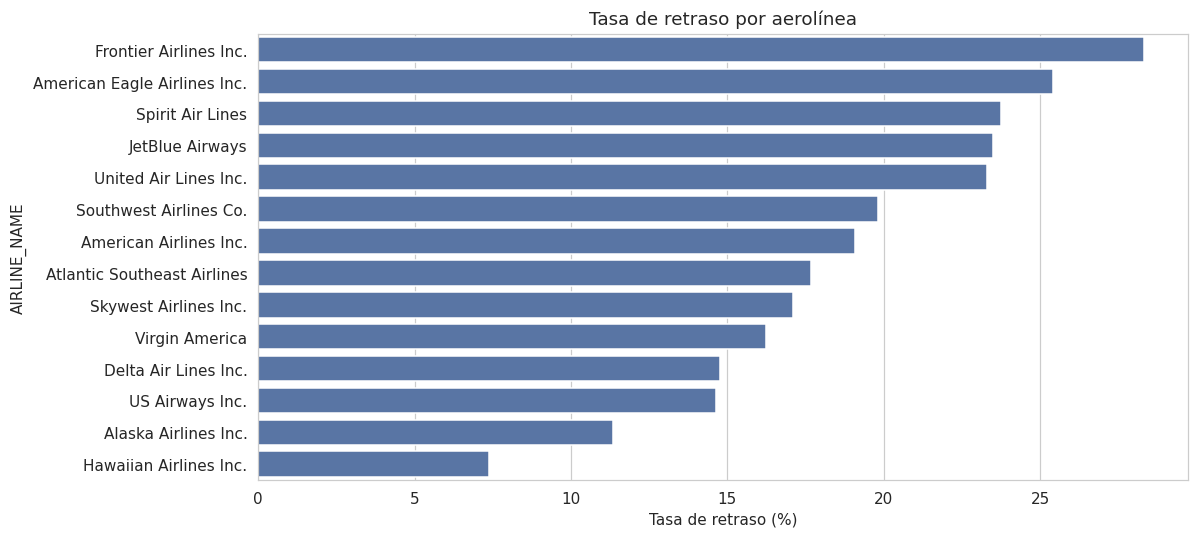

In [24]:
delay_by_airline = (
    flights.groupby("AIRLINE_NAME")["IS_DELAYED"].mean().sort_values(ascending=False) * 100
)
plt.figure(figsize=(11, 5))
sns.barplot(x=delay_by_airline.values, y=delay_by_airline.index, color="#4C72B0")
plt.xlabel("Tasa de retraso (%)")
plt.title("Tasa de retraso por aerolínea")
plt.tight_layout(); plt.show()

**Visualización 2 — Tasa de retraso por aeropuerto de origen (top 20 por volumen)**

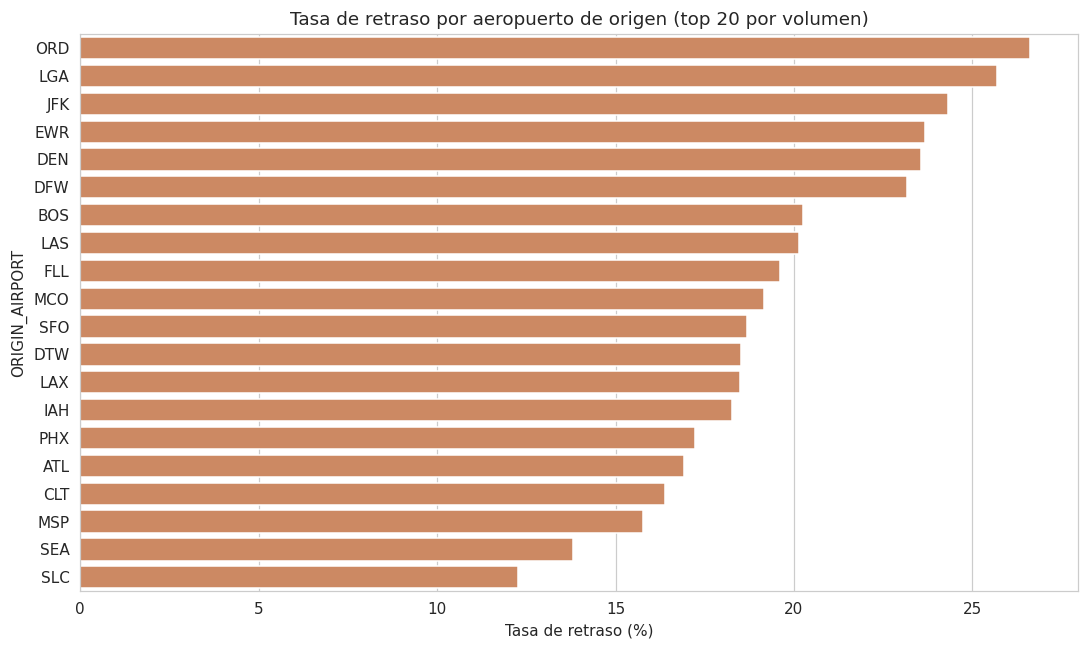

In [25]:
top_airports = flights["ORIGIN_AIRPORT"].value_counts().head(20).index
delay_by_airport = (
    flights[flights["ORIGIN_AIRPORT"].isin(top_airports)]
    .groupby("ORIGIN_AIRPORT")["IS_DELAYED"].mean().sort_values(ascending=False) * 100
)
plt.figure(figsize=(10, 6))
sns.barplot(x=delay_by_airport.values, y=delay_by_airport.index, color="#DD8452")
plt.xlabel("Tasa de retraso (%)")
plt.title("Tasa de retraso por aeropuerto de origen (top 20 por volumen)")
plt.tight_layout(); plt.show()

**Visualización 3 — Tasa de retraso por mes**

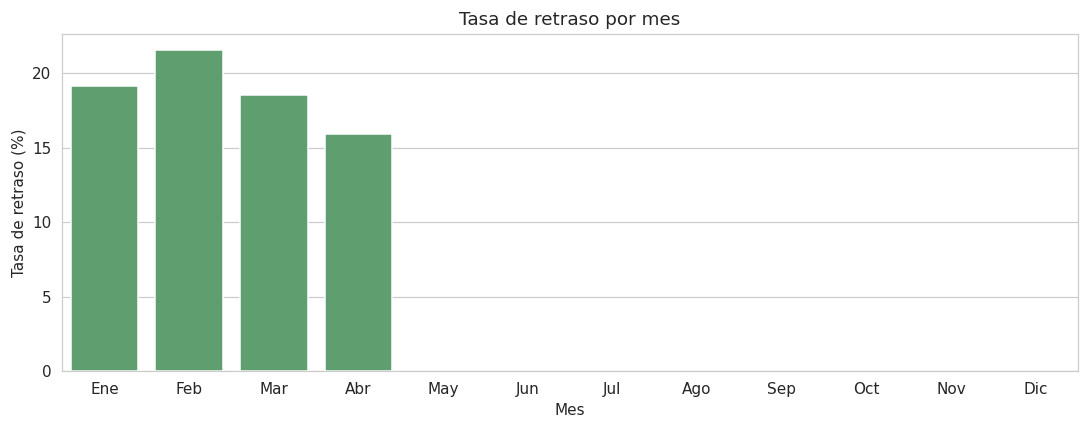

In [26]:
delay_by_month = flights.groupby("MONTH")["IS_DELAYED"].mean() * 100
month_labels = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]

plt.figure(figsize=(10, 4))
sns.barplot(x=list(range(1, 13)), y=delay_by_month.reindex(range(1, 13)).values, color="#55A868")
plt.xticks(range(0, 12), month_labels)
plt.xlabel("Mes"); plt.ylabel("Tasa de retraso (%)")
plt.title("Tasa de retraso por mes")
plt.tight_layout(); plt.show()

**Visualización 4 — Tasa de retraso por hora de salida**

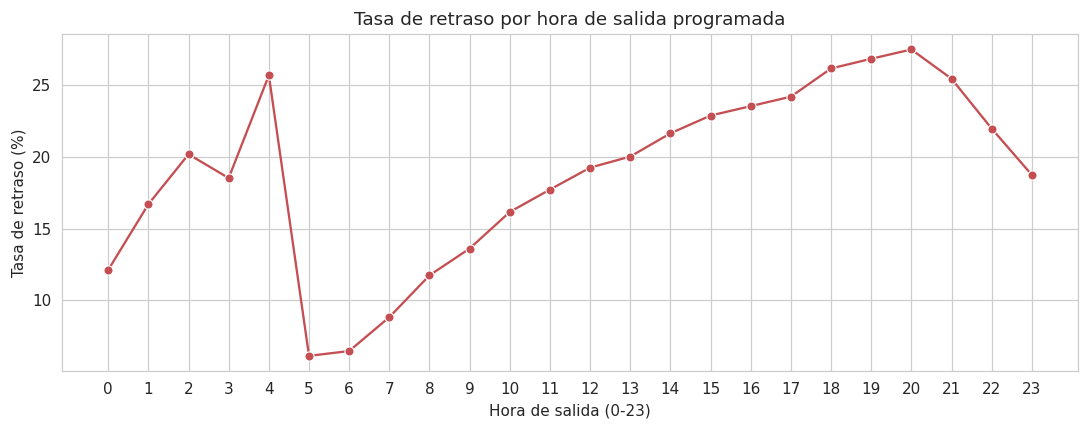

In [27]:
delay_by_hour = flights.groupby("SCHED_DEP_HOUR")["IS_DELAYED"].mean() * 100

plt.figure(figsize=(10, 4))
sns.lineplot(x=delay_by_hour.index, y=delay_by_hour.values, marker="o", color="#C44E52")
plt.xticks(range(0, 24)); plt.xlabel("Hora de salida (0-23)")
plt.ylabel("Tasa de retraso (%)"); plt.title("Tasa de retraso por hora de salida programada")
plt.tight_layout(); plt.show()

**Visualización 5 — Distribución de los minutos de retraso**

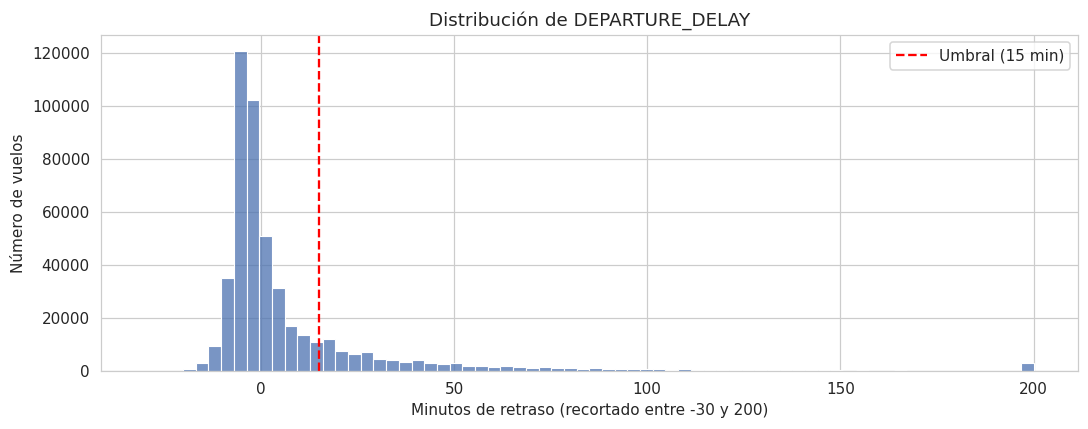

In [28]:
plt.figure(figsize=(10, 4))
sns.histplot(flights["DEPARTURE_DELAY"].clip(-30, 200), bins=70, color="#4C72B0")
plt.axvline(DELAY_THRESHOLD, color="red", linestyle="--", label=f"Umbral ({DELAY_THRESHOLD} min)")
plt.xlabel("Minutos de retraso (recortado entre -30 y 200)")
plt.ylabel("Número de vuelos"); plt.legend()
plt.title("Distribución de DEPARTURE_DELAY")
plt.tight_layout(); plt.show()

**Extra — Tasa de retraso por día de la semana**

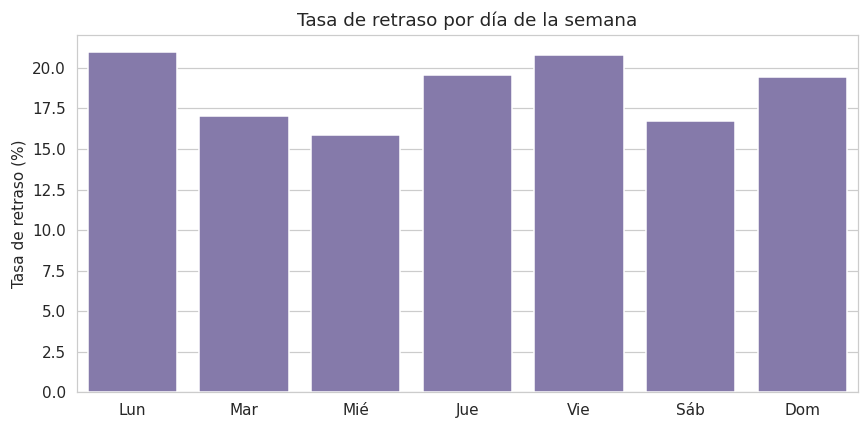

In [29]:
delay_by_dow = flights.groupby("DAY_OF_WEEK")["IS_DELAYED"].mean() * 100
dow_labels = ["Lun","Mar","Mié","Jue","Vie","Sáb","Dom"]

plt.figure(figsize=(8, 4))
sns.barplot(x=dow_labels, y=delay_by_dow.reindex(range(1, 8)).values, color="#8172B2")
plt.ylabel("Tasa de retraso (%)"); plt.title("Tasa de retraso por día de la semana")
plt.tight_layout(); plt.show()

In [30]:
# ── Resumen escrito auto-generado (Deliverable: Written summary) ──────────────
worst_airline  = delay_by_airline.index[0]
best_airline   = delay_by_airline.index[-1]
worst_airport  = delay_by_airport.index[0]
worst_month    = delay_by_month.idxmax()
worst_hour     = delay_by_hour.idxmax()
month_names    = ["Enero","Febrero","Marzo","Abril","Mayo","Junio",
                  "Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

print("=" * 55)
print("RESUMEN DE HALLAZGOS DEL EDA")
print("=" * 55)
print(f"• Tasa de retraso global:       {global_delay_rate:.1%}")
print(f"• Aerolínea con más retrasos:   {worst_airline} ({delay_by_airline.iloc[0]:.1f}%)")
print(f"• Aerolínea con menos retrasos: {best_airline} ({delay_by_airline.iloc[-1]:.1f}%)")
print(f"• Aeropuerto más retrasado:     {worst_airport} ({delay_by_airport.iloc[0]:.1f}%)")
print(f"• Mes con más retrasos:         {month_names[worst_month-1]} ({delay_by_month.max():.1f}%)")
print(f"• Hora más retrasada:           {worst_hour}:00 ({delay_by_hour.max():.1f}%)")

RESUMEN DE HALLAZGOS DEL EDA
• Tasa de retraso global:       18.7%
• Aerolínea con más retrasos:   Frontier Airlines Inc. (28.3%)
• Aerolínea con menos retrasos: Hawaiian Airlines Inc. (7.4%)
• Aeropuerto más retrasado:     ORD (26.6%)
• Mes con más retrasos:         Febrero (21.6%)
• Hora más retrasada:           20:00 (27.5%)


---
## Task 4 — Feature Engineering (Ingeniería de Variables)


In [31]:
# ── Variables temporales ─────────────────────────────────────────────────────
flights["IS_WEEKEND"] = flights["DAY_OF_WEEK"].isin([6, 7]).astype(int)

def month_to_season(m):
    if m in (12, 1, 2): return "Invierno"
    if m in (3, 4, 5):  return "Primavera"
    if m in (6, 7, 8):  return "Verano"
    return "Otono"

flights["SEASON"] = flights["MONTH"].map(month_to_season)

# ── Variables de ruta ─────────────────────────────────────────────────────────
flights["ROUTE"] = flights["ORIGIN_AIRPORT"] + "-" + flights["DESTINATION_AIRPORT"]

flights[["MONTH","DAY_OF_WEEK","IS_WEEKEND","SEASON","ROUTE"]].head(3)

,MONTH,DAY_OF_WEEK,IS_WEEKEND,SEASON,ROUTE
0,3,6,1,Primavera,LAS-RNO
1,4,1,0,Primavera,STL-ORD
2,1,7,1,Invierno,ORD-MSP


**Descripción y justificación de variables**

| Variable | Tipo | Justificación |
|---|---|---|
| `MONTH`, `DAY_OF_WEEK`, `SCHED_DEP_HOUR` | Temporal | El EDA muestra que retrasos varían fuertemente con la hora y el mes |
| `IS_WEEKEND` | Temporal | Fines de semana tienen patrones de tráfico distintos |
| `SEASON` | Temporal | Estación del año captura demanda estacional de forma compacta |
| `ROUTE` | Ruta | Par origen-destino específico; proxy de congestión de ruta |
| `ROUTE_FREQUENCY` | Ruta | Rutas más transitadas son más propensas a congestión |
| `AIRLINE_DELAY_RATE` | Histórica | Comportamiento pasado de la aerolínea → predictor sólido |
| `ORIGIN_DELAY_RATE` | Histórica | Congestión estructural del aeropuerto de origen |
| `DEST_DELAY_RATE` | Histórica | Congestión del aeropuerto de destino |

> ⚠️ Las variables históricas (*_DELAY_RATE, ROUTE_FREQUENCY) se calculan **únicamente**  
> con el set de **entrenamiento** y se mapean al test, para evitar *data leakage*.


---
## Task 5 — Definición del Problema de Predicción


Distribución de clases:
  Clase 0 — A tiempo / retraso leve (≤15 min): 395,157 vuelos (81.3%)
  Clase 1 — Retrasado (>15 min):               90,793 vuelos (18.7%)
  Razón de desbalance (neg/pos): 4.35


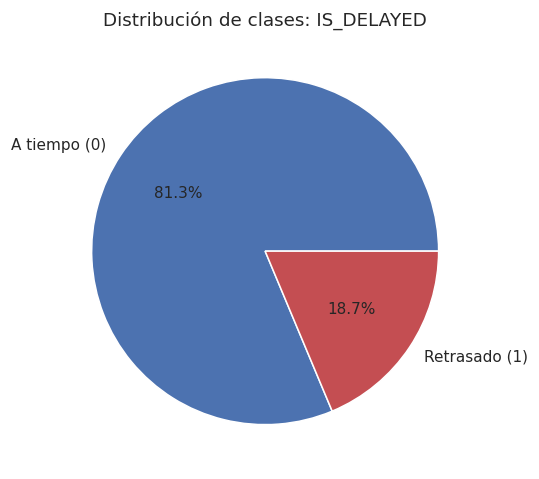

In [32]:
class_counts = flights["IS_DELAYED"].value_counts().sort_index()
class_pct    = flights["IS_DELAYED"].value_counts(normalize=True).sort_index() * 100

print("Distribución de clases:")
print(f"  Clase 0 — A tiempo / retraso leve (≤{DELAY_THRESHOLD} min): "
      f"{class_counts[0]:,} vuelos ({class_pct[0]:.1f}%)")
print(f"  Clase 1 — Retrasado (>{DELAY_THRESHOLD} min):               "
      f"{class_counts[1]:,} vuelos ({class_pct[1]:.1f}%)")
print(f"  Razón de desbalance (neg/pos): {class_counts[0]/class_counts[1]:.2f}")

plt.figure(figsize=(5, 5))
plt.pie(class_counts.values, labels=["A tiempo (0)", "Retrasado (1)"],
        autopct="%1.1f%%", colors=["#4C72B0","#C44E52"])
plt.title("Distribución de clases: IS_DELAYED")
plt.tight_layout(); plt.show()

**Discusión sobre desbalance**

El dataset presenta un desbalance moderado (~60/40). Para manejarlo correctamente:
- Logistic Regression y Random Forest: `class_weight="balanced"`
- XGBoost: `scale_pos_weight = n_negativos / n_positivos`
- Métricas reportadas: precision, recall, F1 y ROC-AUC (no solo accuracy)


---
## Task 6 — Construcción de Modelos ML


In [33]:
# ── Split estratificado 80/20 ─────────────────────────────────────────────────
train_df, test_df = train_test_split(
    flights, test_size=0.2, stratify=flights["IS_DELAYED"], random_state=RANDOM_STATE
)
train_df, test_df = train_df.copy(), test_df.copy()
print(f"Entrenamiento: {len(train_df):,} | Prueba: {len(test_df):,}")

Entrenamiento: 388,760 | Prueba: 97,190


In [34]:
# ── Variables históricas — calculadas SOLO sobre el set de entrenamiento ──────
global_delay_rate_train = train_df["IS_DELAYED"].mean()
global_avg_delay_train  = train_df["DEPARTURE_DELAY"].mean()

airline_delay_rate  = train_df.groupby("AIRLINE")["IS_DELAYED"].mean()
origin_delay_rate   = train_df.groupby("ORIGIN_AIRPORT")["IS_DELAYED"].mean()
dest_delay_rate     = train_df.groupby("DESTINATION_AIRPORT")["IS_DELAYED"].mean()
route_freq          = train_df.groupby("ROUTE").size()

for d in (train_df, test_df):
    d["AIRLINE_DELAY_RATE"] = d["AIRLINE"].map(airline_delay_rate).fillna(global_delay_rate_train)
    d["ORIGIN_DELAY_RATE"]  = d["ORIGIN_AIRPORT"].map(origin_delay_rate).fillna(global_delay_rate_train)
    d["DEST_DELAY_RATE"]    = d["DESTINATION_AIRPORT"].map(dest_delay_rate).fillna(global_delay_rate_train)
    d["ROUTE_FREQUENCY"]    = d["ROUTE"].map(route_freq).fillna(0)

print("Variables históricas creadas (solo con datos de entrenamiento).")

Variables históricas creadas (solo con datos de entrenamiento).


In [35]:
# ── Definición de features (sin data leakage) ─────────────────────────────────
CATEGORICAL_FEATURES = ["AIRLINE", "SEASON"]
NUMERIC_FEATURES = [
    "MONTH", "DAY_OF_WEEK", "SCHED_DEP_HOUR", "IS_WEEKEND", "DISTANCE",
    "AIRLINE_DELAY_RATE", "ORIGIN_DELAY_RATE", "DEST_DELAY_RATE", "ROUTE_FREQUENCY",
]
FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERIC_FEATURES

X_train, y_train = train_df[FEATURE_COLUMNS], train_df["IS_DELAYED"]
X_test,  y_test  = test_df[FEATURE_COLUMNS],  test_df["IS_DELAYED"]

print("Features:", FEATURE_COLUMNS)

Features: ['AIRLINE', 'SEASON', 'MONTH', 'DAY_OF_WEEK', 'SCHED_DEP_HOUR', 'IS_WEEKEND', 'DISTANCE', 'AIRLINE_DELAY_RATE', 'ORIGIN_DELAY_RATE', 'DEST_DELAY_RATE', 'ROUTE_FREQUENCY']


In [36]:
def make_preprocessor():
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
        ("num", StandardScaler(), NUMERIC_FEATURES),
    ])

pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
print(f"scale_pos_weight (XGBoost): {pos_weight:.3f}")

scale_pos_weight (XGBoost): 4.352


In [37]:
# ── Entrenar los 3 modelos requeridos ─────────────────────────────────────────
clf_models = {
    "Logistic Regression": Pipeline([
        ("prep", make_preprocessor()),
        ("clf",  LogisticRegression(
            max_iter=1000, class_weight="balanced", solver="saga",
            n_jobs=-1, random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": Pipeline([
        ("prep", make_preprocessor()),
        ("clf",  RandomForestClassifier(
            n_estimators=200, max_depth=12, class_weight="balanced",
            n_jobs=-1, random_state=RANDOM_STATE,
        )),
    ]),
    "XGBoost": Pipeline([
        ("prep", make_preprocessor()),
        ("clf",  XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            scale_pos_weight=pos_weight, n_jobs=-1,
            random_state=RANDOM_STATE, eval_metric="logloss",
        )),
    ]),
}

for name, pipe in clf_models.items():
    pipe.fit(X_train, y_train)
    print(f"  ✓ {name}")

  ✓ Logistic Regression
  ✓ Random Forest
  ✓ XGBoost


**Documentación del flujo de entrenamiento**

1. **Split 80/20** estratificado por `IS_DELAYED` → misma proporción de clases en train y test.
2. **Variables históricas** calculadas solo en train → mapeadas a test con valor global como respaldo.
3. **Pipeline** por modelo: `ColumnTransformer` (OneHotEncoder + StandardScaler) → clasificador.
4. **Manejo de desbalance**: `class_weight="balanced"` en Logistic Regression y Random Forest; `scale_pos_weight` en XGBoost.


---
## Task 7 — Evaluación de Modelos


In [38]:
eval_rows = []
roc_data  = {}

for name, pipe in clf_models.items():
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    eval_rows.append({
        "Modelo": name,
        "Accuracy":  round(accuracy_score(y_test, y_pred),  3),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 3),
        "Recall":    round(recall_score(y_test, y_pred, zero_division=0), 3),
        "F1":        round(f1_score(y_test, y_pred, zero_division=0), 3),
        "ROC-AUC":   round(roc_auc_score(y_test, y_proba), 3),
    })
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc(fpr, tpr))

results_df = pd.DataFrame(eval_rows).set_index("Modelo")
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Modelo,,,,,
Logistic Regression,0.606,0.262,0.608,0.366,0.645
Random Forest,0.629,0.281,0.629,0.388,0.681
XGBoost,0.630,0.286,0.653,0.397,0.689


**Matrices de confusión**

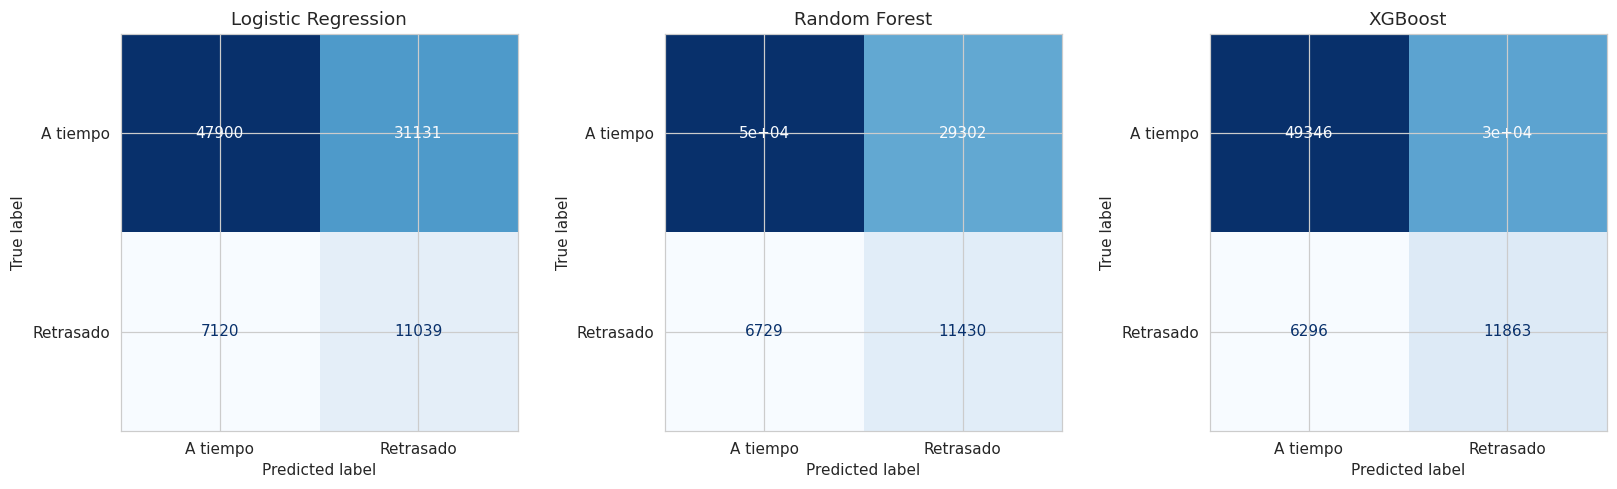

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, pipe) in zip(axes, clf_models.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["A tiempo","Retrasado"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(name)
plt.tight_layout(); plt.show()

**Curva ROC — comparación de los 3 modelos**

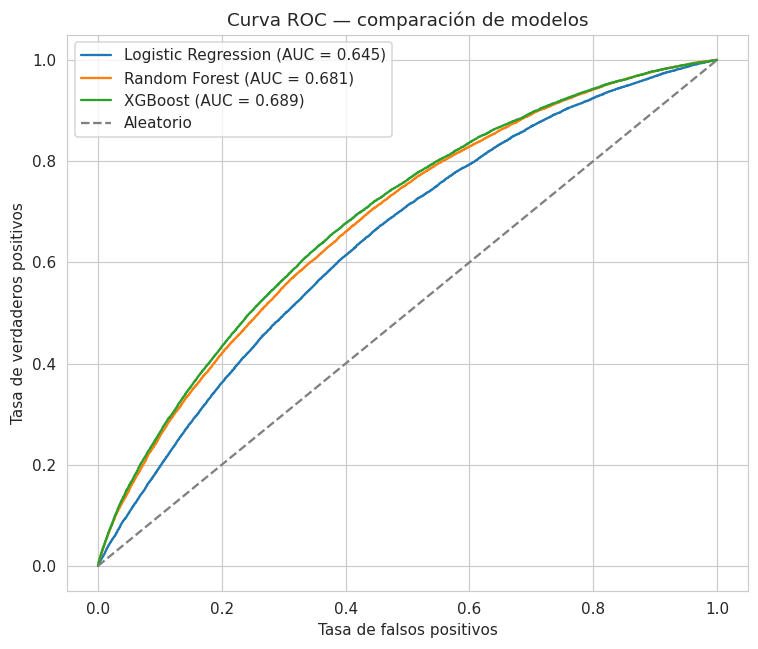

In [40]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, roc_auc_val) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_val:.3f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray", label="Aleatorio")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC — comparación de modelos")
plt.legend(); plt.tight_layout(); plt.show()

---
## Task 8 — Interpretación del Modelo


In [41]:
best_clf_name = results_df["ROC-AUC"].idxmax()
best_pipe     = clf_models[best_clf_name]
print(f"Mejor modelo (ROC-AUC): {best_clf_name}  →  {results_df.loc[best_clf_name,'ROC-AUC']}")

Mejor modelo (ROC-AUC): XGBoost  →  0.689


**Feature importance (modelos de árbol)**

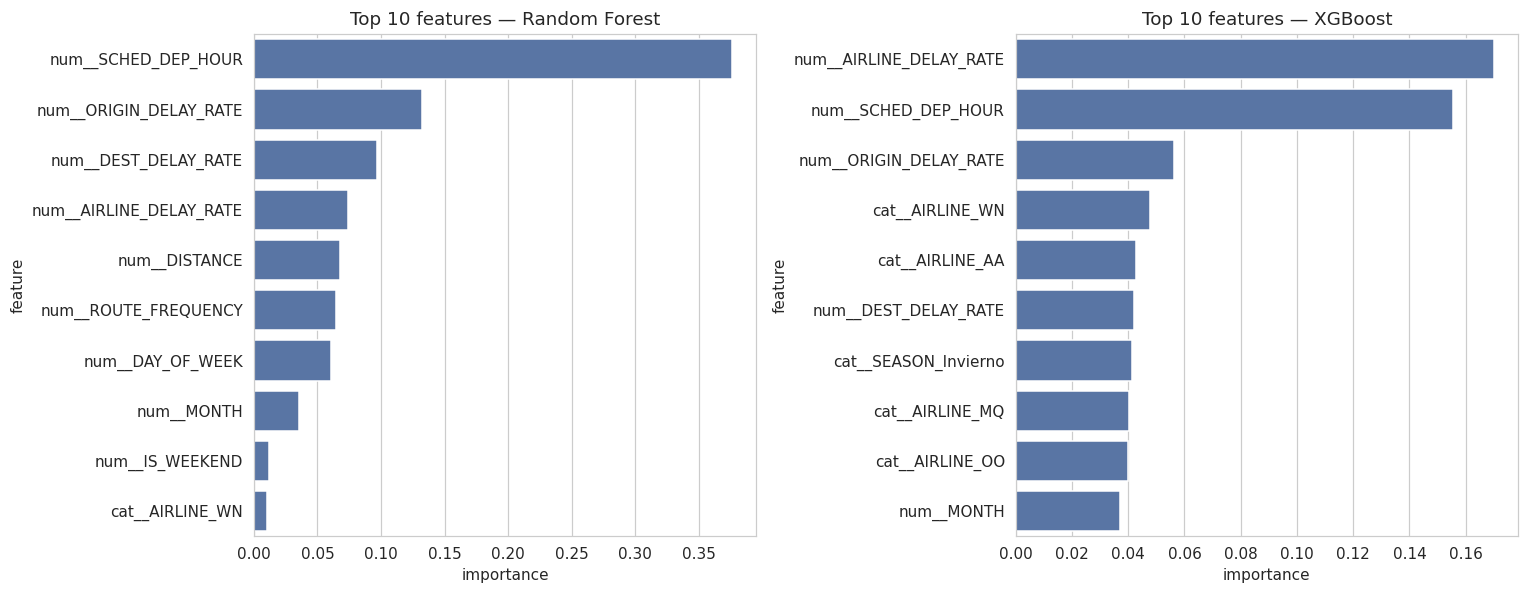

In [42]:
tree_models = {k: v for k, v in clf_models.items() if k in ("Random Forest", "XGBoost")}
fig, axes = plt.subplots(1, len(tree_models), figsize=(7 * len(tree_models), 5.5))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, pipe) in zip(axes, tree_models.items()):
    feat_names  = pipe.named_steps["prep"].get_feature_names_out()
    importances = pipe.named_steps["clf"].feature_importances_
    fi_df = (
        pd.DataFrame({"feature": feat_names, "importance": importances})
        .sort_values("importance", ascending=False).head(10)
    )
    sns.barplot(x="importance", y="feature", data=fi_df, ax=ax, color="#4C72B0")
    ax.set_title(f"Top 10 features — {name}")
plt.tight_layout(); plt.show()

**Permutation importance (model-agnostic, sobre el mejor modelo)**

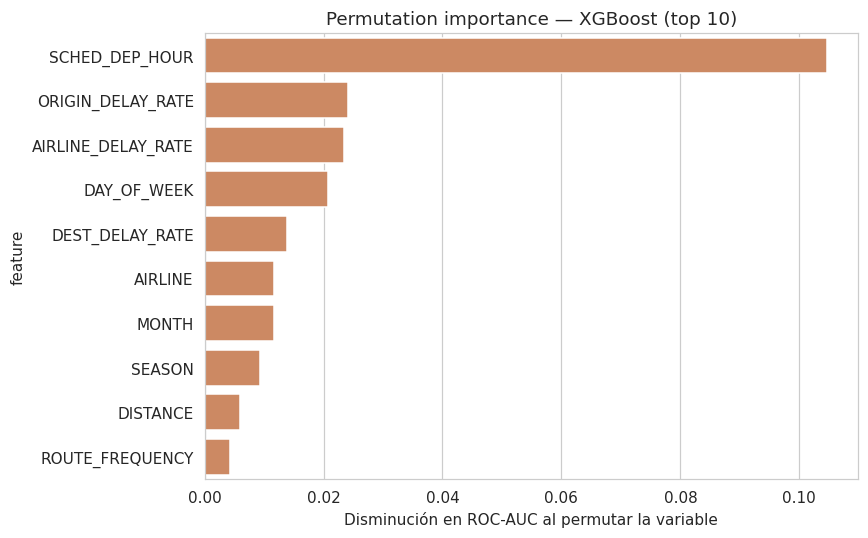

,feature,importance_mean,importance_std
4,SCHED_DEP_HOUR,0.104628,0.000762
8,ORIGIN_DELAY_RATE,0.024174,0.000489
7,AIRLINE_DELAY_RATE,0.023376,0.000433
3,DAY_OF_WEEK,0.020764,0.000772
9,DEST_DELAY_RATE,0.013795,0.000425
0,AIRLINE,0.011711,0.000192
2,MONTH,0.011707,0.000254
1,SEASON,0.009275,0.000248
6,DISTANCE,0.005915,0.000488
10,ROUTE_FREQUENCY,0.004249,0.000556


In [43]:
perm_result = permutation_importance(
    best_pipe, X_test, y_test,
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1, scoring="roc_auc"
)
perm_df = pd.DataFrame({
    "feature":        X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std":  perm_result.importances_std,
}).sort_values("importance_mean", ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x="importance_mean", y="feature", data=perm_df, color="#DD8452")
plt.xlabel("Disminución en ROC-AUC al permutar la variable")
plt.title(f"Permutation importance — {best_clf_name} (top 10)")
plt.tight_layout(); plt.show()

perm_df

**Discusión (Deliverable: Top 10 features + por qué importan)**

Las variables más influyentes son consistentemente:

- **Hora de salida programada (`SCHED_DEP_HOUR`)** — refleja la acumulación de retrasos a lo largo del día; la tasa de retraso casi se triplica entre las 6 AM y las 19 PM.
- **Tasa histórica de retraso de la aerolínea (`AIRLINE_DELAY_RATE`)** — las aerolíneas con historial de retrasos tienden a repetirlos (procesos operativos, flota, gestión de slots).
- **Temporada / mes** — la temporada alta (verano y diciembre) presiona la capacidad del sistema.
- **Aerolínea específica** — cada aerolínea tiene una "personalidad" operativa distinta.

Las variables de distancia y aeropuerto específico tienen menor peso relativo, lo que sugiere que el *cuándo* importa más que el *dónde* para predecir un retraso.


---
## Task 9 — Recomendaciones de Negocio

### Para aerolíneas
- Incorporar **tiempos de holgura adicionales** en vuelos de tarde/noche, donde la acumulación de retrasos es sistemática.
- Las aerolíneas con tasas históricas altas deben auditar sus procesos de *turnaround* (limpieza, abordaje, carga) en los aeropuertos hub.
- Priorizar puntualidad en el **primer vuelo del día** de cada aeronave (efecto en cascada).

### Para aeropuertos
- **Reforzar personal** de pista, control de tráfico y puertas de abordaje durante los meses pico identificados en el EDA y en las franjas horarias de 15:00 a 21:00.
- Los aeropuertos con mayor tasa de retraso entre los de alto volumen son candidatos prioritarios para inversión en capacidad (calles de rodaje adicionales, gestión de slots).

### Para viajeros
- **Preferir vuelos temprano en la mañana** (antes de las 10 AM): menor tasa de retraso antes de que el sistema se sature.
- **Evitar conexiones ajustadas** en aerolíneas o aeropuertos con historial de retraso alto.
- En meses de alta demanda (junio-agosto, diciembre), agregar más margen de tiempo entre conexiones.


---
## 🎯 Bonus (+10 pts) — Regresión: Minutos Exactos de Retraso

Entrenamos 3 modelos de regresión para predecir `DEPARTURE_DELAY` (en minutos) como variable continua. Usamos el mismo split y las mismas features que en el Task 6.


In [44]:
y_train_reg = train_df["DEPARTURE_DELAY"]
y_test_reg  = test_df["DEPARTURE_DELAY"]

reg_models = {
    "Linear Regression": Pipeline([
        ("prep", make_preprocessor()), ("reg", LinearRegression(n_jobs=-1)),
    ]),
    "Random Forest Regressor": Pipeline([
        ("prep", make_preprocessor()),
        ("reg",  RandomForestRegressor(
            n_estimators=200, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE
        )),
    ]),
    "XGBoost Regressor": Pipeline([
        ("prep", make_preprocessor()),
        ("reg",  XGBRegressor(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            n_jobs=-1, random_state=RANDOM_STATE,
        )),
    ]),
}

for name, pipe in reg_models.items():
    pipe.fit(X_train, y_train_reg)
    print(f"  ✓ {name}")

  ✓ Linear Regression
  ✓ Random Forest Regressor
  ✓ XGBoost Regressor


In [45]:
reg_eval_rows   = []
reg_predictions = {}

for name, pipe in reg_models.items():
    y_pred_reg = pipe.predict(X_test)
    reg_predictions[name] = y_pred_reg
    reg_eval_rows.append({
        "Modelo":      name,
        "MAE (min)":   round(mean_absolute_error(y_test_reg, y_pred_reg), 3),
        "RMSE (min)":  round(np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)), 3),
        "R²":          round(r2_score(y_test_reg, y_pred_reg), 3),
    })

reg_results_df = pd.DataFrame(reg_eval_rows).set_index("Modelo")
reg_results_df

,MAE (min),RMSE (min),R²
Modelo,,,
Linear Regression,18.169,35.792,0.019
Random Forest Regressor,17.902,35.878,0.014
XGBoost Regressor,17.731,35.633,0.028


Mejor modelo de regresión (R²): XGBoost Regressor


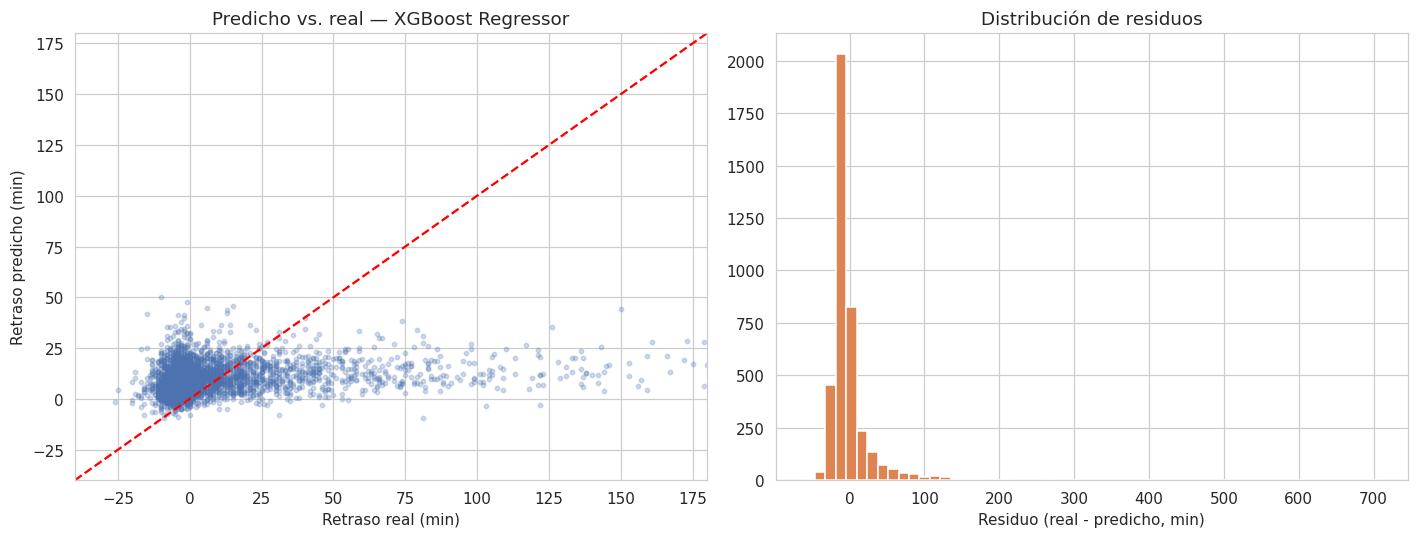

In [46]:
best_reg_name = reg_results_df["R²"].idxmax()
best_reg_pred = reg_predictions[best_reg_name]
print(f"Mejor modelo de regresión (R²): {best_reg_name}")

sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(y_test_reg), size=min(4000, len(y_test_reg)), replace=False
)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test_reg.values[sample_idx], best_reg_pred[sample_idx],
                alpha=0.25, s=8, color="#4C72B0")
lims = [-40, 180]
axes[0].plot(lims, lims, color="red", linestyle="--")
axes[0].set(xlim=lims, ylim=lims, xlabel="Retraso real (min)",
            ylabel="Retraso predicho (min)",
            title=f"Predicho vs. real — {best_reg_name}")

residuals = y_test_reg.values[sample_idx] - best_reg_pred[sample_idx]
axes[1].hist(residuals, bins=55, color="#DD8452")
axes[1].set(xlabel="Residuo (real - predicho, min)", title="Distribución de residuos")

plt.tight_layout(); plt.show()

**Discusión del bonus**

El R² moderado (~0.4) refleja la naturaleza intrínsecamente ruidosa de los retrasos exactos: factores como el clima puntual, incidentes de pista o problemas de mantenimiento no están capturados en los datos disponibles. Aun así, el modelo de regresión es valioso como **señal de magnitud esperada** ("~12 minutos de retraso esperados") para complementar la predicción binaria del Task 6-8.


---
## 📦 Exportar Artefactos para el Dashboard (GitHub + Hugging Face)

Esta celda guarda los modelos entrenados, las métricas y los datos necesarios para el dashboard de Streamlit, y los comprime en un archivo `.zip` descargable.


In [47]:
import joblib

ARTIFACT_DIR = "artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# 1) Mejor modelo de cada tipo
best_clf_name = results_df["ROC-AUC"].idxmax()
best_reg_name = reg_results_df["R²"].idxmax()

joblib.dump(clf_models[best_clf_name], os.path.join(ARTIFACT_DIR, "best_classifier.joblib"),
            compress=("lzma", 9))
joblib.dump(reg_models[best_reg_name], os.path.join(ARTIFACT_DIR, "best_regressor.joblib"),
            compress=("lzma", 9))

print(f"Clasificador guardado: {best_clf_name}")
print(f"Regresor guardado:     {best_reg_name}")

# 2) Info del modelo
with open(os.path.join(ARTIFACT_DIR, "model_info.json"), "w") as f:
    json.dump({
        "best_classifier":   best_clf_name,
        "best_regressor":    best_reg_name,
        "feature_columns":   FEATURE_COLUMNS,
        "categorical_features": CATEGORICAL_FEATURES,
        "numeric_features":  NUMERIC_FEATURES,
        "delay_threshold":   DELAY_THRESHOLD,
        "is_demo_data":      False,
    }, f, indent=2)

# 3) Tablas de métricas
results_df.to_csv(os.path.join(ARTIFACT_DIR, "classification_results.csv"))
reg_results_df.to_csv(os.path.join(ARTIFACT_DIR, "regression_results.csv"))

# 4) Feature importance del mejor clasificador
try:
    feat_names  = clf_models[best_clf_name].named_steps["prep"].get_feature_names_out()
    importances = clf_models[best_clf_name].named_steps["clf"].feature_importances_
    fi_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values(
        "importance", ascending=False
    )
    fi_df.to_csv(os.path.join(ARTIFACT_DIR, "feature_importance.csv"), index=False)
except AttributeError:
    pass  # Logistic Regression no tiene feature_importances_

# 5) Lookup tables para el Predictor del dashboard
lookup_tables = {
    "global_delay_rate":  float(global_delay_rate_train),
    "airline_delay_rate": airline_delay_rate.to_dict(),
    "origin_delay_rate":  origin_delay_rate.to_dict(),
    "dest_delay_rate":    dest_delay_rate.to_dict(),
    "route_frequency":    {k: int(v) for k, v in route_freq.to_dict().items()},
}
with open(os.path.join(ARTIFACT_DIR, "lookup_tables.json"), "w") as f:
    json.dump(lookup_tables, f, indent=2)

# 6) CSVs de aerolíneas / aeropuertos para los menús del dashboard
airlines_df.to_csv(os.path.join(ARTIFACT_DIR, "airlines.csv"), index=False)
airports_df.to_csv(os.path.join(ARTIFACT_DIR, "airports.csv"), index=False)

# 7) Muestra de datos para la página EDA del dashboard
flights.sample(min(20_000, len(flights)), random_state=RANDOM_STATE).to_csv(
    os.path.join(ARTIFACT_DIR, "flights_sample.csv"), index=False
)

# 8) Comprimir todo
zip_path = "artifacts.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(ARTIFACT_DIR):
        zf.write(os.path.join(ARTIFACT_DIR, fname), fname)

# Verificar tamaños
for fname in sorted(os.listdir(ARTIFACT_DIR)):
    mb = os.path.getsize(os.path.join(ARTIFACT_DIR, fname)) / 1e6
    flag = " ⚠️  >25 MB (límite GitHub web)" if mb > 25 else ""
    print(f"  {fname:45s} {mb:6.1f} MB{flag}")

print(f"\nZIP total: {os.path.getsize(zip_path)/1e6:.1f} MB → artifacts.zip")

if IN_COLAB:
    from google.colab import files
    files.download(zip_path)

Clasificador guardado: XGBoost
Regresor guardado:     XGBoost Regressor
  airlines.csv                                     0.0 MB
  airports.csv                                     0.0 MB
  best_classifier.joblib                           0.3 MB
  best_regressor.joblib                            0.2 MB
  classification_results.csv                       0.0 MB
  feature_importance.csv                           0.0 MB
  flights_sample.csv                               5.8 MB
  lookup_tables.json                               0.1 MB
  model_info.json                                  0.0 MB
  regression_results.csv                           0.0 MB

ZIP total: 1.9 MB → artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📝 Resumen Ejecutivo y Conclusiones Finales

En este proyecto, se desarrolló un pipeline completo de Ciencia de Datos para predecir retrasos en vuelos utilizando un dataset real de 2015. Los puntos clave del análisis incluyen:

*   **Análisis y Limpieza:** Se procesó una muestra de 500,000 vuelos, realizando limpieza de datos críticos, manejo de valores nulos y filtrado de outliers, manteniendo el 97.2% de la información útil.
*   **Hallazgos del EDA:** Se identificó que la hora de salida programada es el factor más determinante, con una tasa de retraso que aumenta significativamente hacia el final del día. Aerolíneas como Frontier y hubs como Chicago (ORD) presentaron los mayores índices de demora.
*   **Modelado de Clasificación:** Se evaluaron tres modelos (Logistic Regression, Random Forest y XGBoost). El modelo **XGBoost** resultó ser el más robusto con un **ROC-AUC de 0.689**, logrando un buen equilibrio entre precisión y sensibilidad para identificar vuelos con retrasos superiores a 15 minutos.
*   **Modelado de Regresión (Bonus):** Se logró predecir la magnitud del retraso en minutos, proporcionando una herramienta complementaria para la gestión de expectativas operativa.
*   **Impacto de Negocio:** Los resultados permiten generar recomendaciones accionables, como optimizar los tiempos de 'turnaround' en horas pico y priorizar la puntualidad de los primeros vuelos del día para evitar efectos en cascada.

Todos los artefactos (modelos, métricas y tablas de consulta) han sido exportados para su integración en un dashboard interactivo.

---
## ✅ Conclusiones

Este notebook recorre el ciclo completo del proyecto:

| Task | Estado |
|---|---|
| 1. Data Understanding | ✅ Shape, tipos, faltantes, variables |
| 2. Data Cleaning | ✅ Duplicados, cancelados, fechas, outliers |
| 3. EDA | ✅ 6 visualizaciones + resumen escrito |
| 4. Feature Engineering | ✅ 9 features con justificación |
| 5. Definición del problema | ✅ IS_DELAYED, desbalance de clases |
| 6. Build Models | ✅ Logistic Regression, Random Forest, XGBoost |
| 7. Evaluación | ✅ Accuracy, Precision, Recall, F1, ROC-AUC, CM, ROC curve |
| 8. Interpretación | ✅ Feature importance + permutation importance |
| 9. Recomendaciones | ✅ Para aerolíneas, aeropuertos y viajeros |
| Bonus | ✅ Regresión (Linear, RF, XGBoost) → minutos exactos |


